In [10]:
import sys
from pathlib import Path

# Make sure the project root and lb-foraging are on the path
ROOT = Path(".").resolve()
LBF = ROOT / "lb-foraging"
for p in [str(ROOT), str(LBF)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print("Project root:", ROOT)

Project root: /home/stanimeros/Projects/thesslink-rl


In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from navigation_train import (
    train_ppo, train_dqn, train_qlearning,
    _eval_navigation, _discretize_nav, _NAV_ACTIONS,
    MODEL_DIR, get_history_path,
)

print("Imports OK")

Imports OK


In [12]:
import pickle

GRID_SIZES = [8]
ALGOS = ["ppo", "dqn", "qlearning"]


def cumulative_avg(values):
    return np.cumsum(values) / np.arange(1, len(values) + 1)


def get_plot_path(algo: str, grid_size: int | str):
    """Path to training_plot_*.png in the model folder."""
    return MODEL_DIR / algo / f"training_plot_{algo}_{str(grid_size)}.png"


def model_exists(algo: str, grid_size: int) -> bool:
    """Check if a trained model file exists."""
    tag = str(grid_size)
    if algo == "ppo":
        return (MODEL_DIR / "ppo" / f"nav_ppo_{tag}.zip").exists()
    elif algo == "dqn":
        return (MODEL_DIR / "dqn" / f"nav_dqn_{tag}.zip").exists()
    else:
        return (MODEL_DIR / "qlearning" / f"nav_qtable_{tag}.pkl").exists()


def history_exists(algo: str, grid_size: int) -> bool:
    """Check if training_history_*.pkl exists (source for plot generation)."""
    return get_history_path(algo, grid_size).exists()


def show_status():
    """Print a table showing which models and plots exist."""
    header = f"{'':12}" + "".join(f"{g:>8}" for g in GRID_SIZES)
    print(header)
    print("-" * (12 + 8 * len(GRID_SIZES)))
    for algo in ALGOS:
        row = f"{algo:<12}"
        for g in GRID_SIZES:
            m = "M" if model_exists(algo, g) else "."
            p = "H" if history_exists(algo, g) else "."
            row += f"  [{m}{p}]  "
        print(row)
    print("\nM=model exists  H=history (.pkl) exists  .=missing")


show_status()

                   8
--------------------
ppo           [MH]  
dqn           [MH]  
qlearning     [MH]  

M=model exists  H=history (.pkl) exists  .=missing


### Σύγκριση PPO, DQN, Q-Learning (combined)

Όλα τα τρία μοντέλα σε ένα figure. Απαιτεί `training_history_*.pkl` από προηγούμενα training runs.

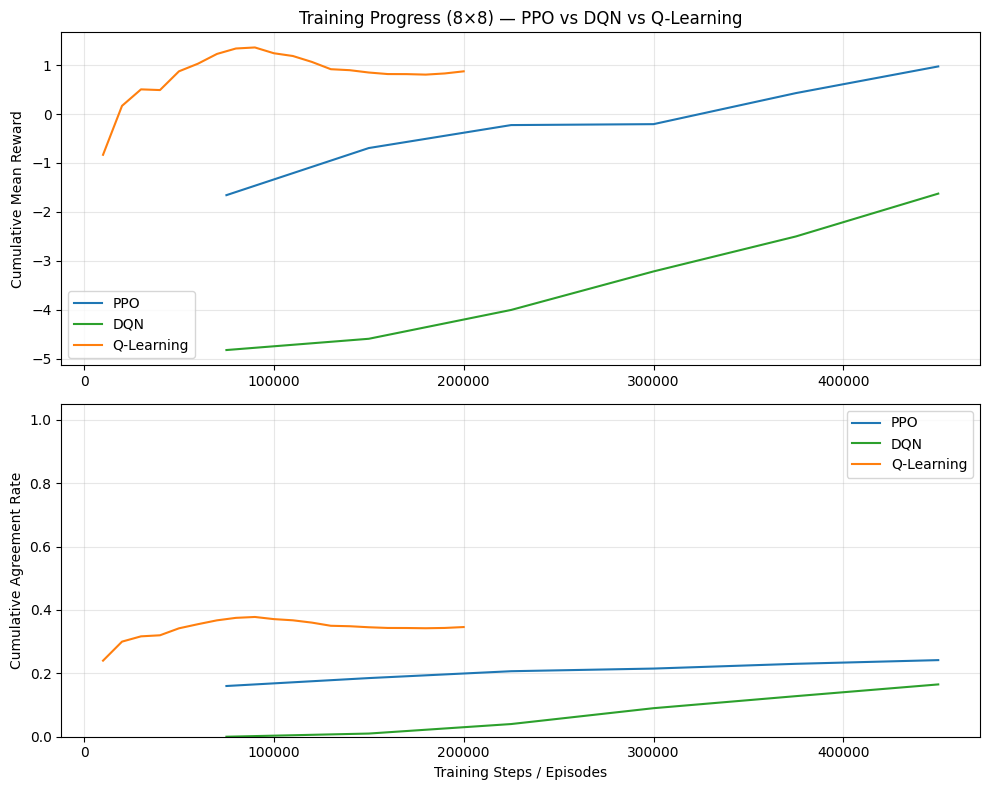

In [13]:
GRID = 8   # ← 8, 32, 64

algo_configs = [("ppo", "PPO", "tab:blue"), ("dqn", "DQN", "tab:green"), ("qlearning", "Q-Learning", "tab:orange")]
histories = {}
for algo, label, color in algo_configs:
    path = get_history_path(algo, GRID)
    if path.exists():
        with open(path, "rb") as f:
            histories[algo] = {"label": label, "color": color, **pickle.load(f)}
    else:
        print(f"  Skipping {label}: {path} not found")

if histories:
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
    for algo, data in histories.items():
        steps = data["steps"]
        cum_reward = cumulative_avg(data["rewards"])
        cum_agreement = cumulative_avg(data["agreement"])
        axes[0].plot(steps, cum_reward, color=data["color"], linewidth=1.5, label=data["label"])
        axes[1].plot(steps, cum_agreement, color=data["color"], linewidth=1.5, label=data["label"])
    axes[0].set_ylabel("Cumulative Mean Reward")
    axes[0].set_title(f"Training Progress ({GRID}×{GRID}) — PPO vs DQN vs Q-Learning")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].set_ylabel("Cumulative Agreement Rate")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel("Training Steps / Episodes")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plot_path = MODEL_DIR / f"training_plot_combined_{GRID}.png"
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run PPO, DQN, Q-Learning first to generate training histories.")